# Домашнее задание 2

## Выбор базовой модели

Для работы была выбрана генеративная модель `AnimeGAN v1`, реализованная на фреймворке PyTorch: https://github.com/ptran1203/pytorch-animeGAN

Модель решает задачу придания изображениям аниме стиля. Генератор получает на вход исходное изображение и выдает на выходе изображение со стилем.

**Сценарий использования модели:** инференс

**Целевая аппаратная платформа:** Xiaomi Redmi Note 9 Pro с процессором Qualcomm Snapdragon 720G

**Основные bottlenecks:** большая задержка при инференсе, большое потребление оперативной памяти

## Выбор и реализация метода ускорения

Выбран метод квантизации модели из формата FP32 в INT8. Это необходимо сделать, чтобы адаптировать модель к запуску на мобильном устройстве.

**Затрагиваемые части:** все слои, содержащие операции `aten::convolution` и `aten::native_batch_norm`.

**Механизм ускорения:**
- уменьшение размера модели в 4 раза (с ~15 МБ до ~3.75 МБ)
- снижение потребления памяти для промежуточных тензоров в 4 раза
- использование аппаратных INT8 инструкций на CPU/GPU и возможность запуска на Hexagon DSP, который работает с INT8 в десятки раз эффективнее, чем CPU с FP32

**Ограничения метода:**
- потеря качества модели
- сложности с квантованием определенных типов моделей или слоев

**Реализация метода при помощи PyTorch:**

Ниже представлен код, проводящий квантование модели в INT8. В качестве бэканда для квантования используется `fbgemm`. Режим применения квантования - QAT (quantization aware training).

## Экспериментальный путь
В процессе выполнения работы был проведен ряд экспериментов:
1. **Post-training quantization.** По его результатам в процессе тестирования наблюдалось существенное падение качества работы модели.
2. **Обучение AnimeGAN с нуля.** Для обучения использовался стандартный датасет с параметрами, аналогичными исходному репозиторию. Эксперимент не закончился успехом — значение функции потерь не снижалось, а качество генерируемых изображений ухудшалось с каждой эпохой.
3. **QAT с полной архитектурой.** Попытки выполнения QAT с одновременным дообучением генератора и дискриминатора приводили к деградации выходных изображений.

**Итоговый подход:** в качестве базового решения использован предобученный генератор, для которого выполнялось QAT-дообучение в режиме предварительного обучения с использованием только контентной составляющей функции потерь. Дискриминатор в процессе квантования не участвовал.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset

from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.image import PeakSignalNoiseRatio

import os
import random
import time
import copy
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from tqdm.auto import tqdm

from datasets import AnimeDataSet, TestPhotosDataset
from trainer import Trainer
from inference import auto_load_weight
from models import GeneratorV1, Discriminator
from utils import normalize_input, denormalize_input, fast_numpyio, read_image, resize_image
from utils.logger import get_logger

In [2]:
print(f"Torch version {torch.__version__}")

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Torch version 2.8.0+cu128
Using cuda device


## Функции и классы

In [2]:
def set_random_seeds(random_seed=0):
    """ Устанавливает random seed в основных библиотеках. """
    
    torch.manual_seed(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(random_seed)
    random.seed(random_seed)


def evaluate_model(model, loader, device):
    """ Рассчитывает метрики SSIM и PSNR на тестовом датасете. """
        
    model.to(device)
    model.eval()

    SSIM = StructuralSimilarityIndexMeasure()
    PSNR = PeakSignalNoiseRatio()

    ssim_values = []
    psnr_values = []

    with torch.no_grad():
        for real_images in tqdm(loader):
            real_images = real_images.to(device)
            anime_images = model(real_images)
    
            real_images = denormalize_input(real_images.cpu())
            anime_images = denormalize_input(anime_images.cpu())
            
            ssim_values.append(SSIM(anime_images, real_images).item())
            psnr_values.append(PSNR(anime_images, real_images).item())

    return np.mean(ssim_values), np.mean(psnr_values)


def measure_inference_latency(
    model,
    device,
    input_size=(1, 3, 512, 512),
    num_samples=100,
    num_warmups=10
):
    """ Измеряет задержку модели. """
    
    model.to(device)
    model.eval()

    x = torch.rand(size=input_size).to(device)

    with torch.no_grad():
        for _ in range(num_warmups):
            _ = model(x)
    torch.cuda.synchronize()

    with torch.no_grad():
        start_time = time.time()
        for _ in tqdm(range(num_samples)):
            _ = model(x)
            torch.cuda.synchronize()
        end_time = time.time()
    elapsed_time = end_time - start_time
    elapsed_time_ave = elapsed_time / num_samples

    return elapsed_time_ave


def save_model(model, model_dir, model_filename):
    """ Сохраняет модель в папку model_dir с именем model_filename. """
    
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)
        
    model_filepath = os.path.join(model_dir, model_filename)
    torch.save(model.state_dict(), model_filepath)


def load_model(model, model_filepath, device):
    """ Загружает модель из файла model_filepath. """
    
    model.load_state_dict(torch.load(model_filepath, map_location=device))
    return model


def save_torchscript_model(model, model_dir, model_filename):
    """ Сохраняет компилированную модель в папку model_dir с именем model_filename. """
    
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)
        
    model_filepath = os.path.join(model_dir, model_filename)
    torch.jit.save(torch.jit.script(model), model_filepath)


def load_torchscript_model(model_filepath, device):
    """ Загружает компилированную модель из файла model_filepath. """
    
    model = torch.jit.load(model_filepath, map_location=device)
    return model

In [3]:
class QuantizedModel(nn.Module):
    def __init__(self, model_fp32, name):
        super(QuantizedModel, self).__init__()
        self.quant = torch.quantization.QuantStub()
        self.dequant = torch.quantization.DeQuantStub()
        self.model_fp32 = model_fp32
        self.name = name

    def forward(self, x):
        x = self.quant(x)
        x = self.model_fp32(x)
        x = self.dequant(x)
        return x

## Основная часть работы

### Настройки

In [5]:
random_seed = 17
cuda_device = torch.device("cuda:1")
cpu_device = torch.device("cpu")

model_dir = "weights"

generator_filename = "generator_hayao_pretrained.pth"
quantized_generator_filename = "generator_hayao_quantized_fbgemm.pth"
generator_filepath = os.path.join(model_dir, generator_filename)
quantized_generator_filepath = os.path.join(model_dir, quantized_generator_filename)

set_random_seeds(random_seed=random_seed)

### Загрузка предобученной модели

In [6]:
# предобученный генератор
generator = auto_load_weight(generator_filepath, map_location=cuda_device)
generator.to(cpu_device)
generator.eval();

In [7]:
# дискриминатор-заглушка (он обучаться не будет)
discriminator = Discriminator(
    'train_photo_Hayao',
    num_layers=2,
    use_sn=False,
    norm_type='instance',
)

### Проведение QAT

In [15]:
class TrainArgs:
    dataset_name = 'train_photo_Hayao'
    real_image_dir = 'data/dataset/train_photo'
    anime_image_dir = 'data/dataset/Hayao'
    test_image_dir = 'data/dataset/test/HR_photo'
    model = 'v1'
    epochs = 0  # не обучаем совместно G и D
    init_epochs = 5  # делаем только отдельный претрейн G
    batch_size = 8
    exp_dir = 'runs_train_photo_Hayao_fbgemm'
    gan_loss = 'lsgan'
    device = str(cuda_device)
    use_sn = False
    amp = False
    cache = False
    save_interval = 1
    debug_samples = 0
    num_workers = 2
    imgsz = [256]
    resize_method = 'crop'
    lr_g = 1e-5
    lr_d = 1e-6
    init_lr = 1e-4
    wadvg = 300.0
    wadvd = 300.0
    gray_adv = False
    wcon = 1.5
    wgra = 3
    wcol = 30
    wtvar = 1
    d_layers = 2
    d_noise = False
    ddp = False
    local_rank = 0

args = TrainArgs()

In [16]:
train_dataset = AnimeDataSet(
    args.anime_image_dir,
    args.real_image_dir,
    args.debug_samples,
    args.cache,
    imgsz=args.imgsz,
    resize_method=args.resize_method,
)

Dataset: real 6656 style 1792, smooth 1792


In [17]:
quantized_generator = copy.deepcopy(generator)
quantized_generator = QuantizedModel(model_fp32=quantized_generator, name=quantized_generator.name)
quantized_generator.train()
quantized_generator.qconfig = torch.quantization.get_default_qat_qconfig("fbgemm")

quantized_generator = torch.quantization.prepare_qat(quantized_generator, inplace=False);

/home/mathuser/anaconda3/envs/mae_microscopy/lib/python3.10/site-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [18]:
# создаем папку для экспериментов и инициализируем логгер
os.makedirs(args.exp_dir, exist_ok=True)
logger = get_logger(os.path.join(args.exp_dir, "train.log"))

# инициализируем трейнер
trainer = Trainer(
    generator=quantized_generator,
    discriminator=discriminator,
    config=args,
    logger=logger,
)

# запустим обучение
trainer.train(train_dataset)

03/28/2026 08:49:24 PM cuda:1
  0%|                                                                                           | 0/224 [00:00<?, ?it/s]/home/mathuser/anaconda3/envs/mae_microscopy/lib/python3.10/site-packages/torch/nn/modules/instancenorm.py:115: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  warnings.warn(
[Init Training G] content loss: 3.384334: 100%|███████████████████████████████████████| 224/224 [02:41<00:00,  1.39it/s]
[ WARN:0@245.614] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
03/28/2026 08:52:19 PM Generated 15 images in 9.213s.
03/28/2026 08:52:19 PM Epoch 0/5
[Init Training G] content loss: 2.831101: 100%|███████████████████████████████████████| 224/224 [02:41<00:00,  1.39it/s]
03/28/2026 08:55:09 PM Generated 15 images in 9.113s.
03/28/2026 08:55:09 PM Epoch 1/5
[Init Training G] con

In [19]:
# конвертируем генератор
quantized_generator.to(cpu_device)
quantized_generator.eval()
quantized_generator = torch.quantization.convert(quantized_generator, inplace=False)

/home/mathuser/anaconda3/envs/mae_microscopy/lib/python3.10/site-packages/torch/ao/quantization/utils.py:408: UserWarning: must run observer before calling calculate_qparams. Returning default values.
  warnings.warn(


### Сохранение и загрузка квантованной модели

In [20]:
# сохранение генератора
save_torchscript_model(
    model=quantized_generator,
    model_dir=model_dir,
    model_filename=quantized_generator_filename
)

In [21]:
# загрузка генератора
quantized_jit_generator = load_torchscript_model(
    model_filepath=quantized_generator_filepath, 
    device=cpu_device
)

### Измерение метрик качества и задержки

Для оценки качества измерялись следующие метрики:
1. **PSNR (Pick Signal-to-Noise Ratio)** - пиковое соотношение сигнала к шуму. Метрика измеряет отношение максимально возможной мощности сигнала к мощности искажающего шума, выраженное в децибелах. Чем выше PSNR, тем лучше качество восстановления изображения.
2. **SSIM (Structural Similarity Index)** - индекс структурного сходства. Это метрика, оценивающая структурное сходство между двумя изображениями на основе восприятия человеком. В отличие от PSNR, учитывает не просто разницу пикселей, а изменения в яркости, контрасте и структуре. Возможное значение метрики находится в диапазоне от 0 до 1.

В качестве тестового датасета используется набор из 45 реальных снимков природных или городских локаций.

In [19]:
test_dataset = TestPhotosDataset('data/dataset/test/HR_photo', imgsz=512)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Test dataset: 45 photos


In [20]:
fp32_eval_ssim, fp32_eval_psnr = evaluate_model(generator, test_loader, cpu_device)
int8_eval_ssim, int8_eval_psnr = evaluate_model(quantized_jit_generator, test_loader, cpu_device)

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

In [21]:
print(
    'FP32 evaluation metrics:\n'
    f'SSIM = {fp32_eval_ssim:.3f}, PSNR = {fp32_eval_psnr:.3f}'
)

print(
    'INT8 evaluation metrics:\n'
    f'SSIM = {int8_eval_ssim:.3f}, PSNR = {int8_eval_psnr:.3f}'
)

FP32 evaluation metrics:
SSIM = 0.685, PSNR = 17.088
INT8 evaluation metrics:
SSIM = 0.341, PSNR = 12.910


По рассчитанным значениям видим, что после квантования в INT8 метрики PSNR и SSIM снизились, что указывает на некоторое снижение качества при использовании квантованной модели. 

Измерим далее задержку моделей с различной точностью хранения весов и при инференсе на CPU или GPU.

In [22]:
fp32_cpu_inference_latency = measure_inference_latency(
    model=generator,
    device=cpu_device)

int8_cpu_inference_latency = measure_inference_latency(
    model=quantized_generator,
    device=cpu_device)

int8_jit_cpu_inference_latency = measure_inference_latency(
    model=quantized_jit_generator,
    device=cpu_device)

fp32_gpu_inference_latency = measure_inference_latency(
    model=generator,
    device=cuda_device)

print("FP32 CPU Inference Latency: {:.2f} ms / sample".format(
    fp32_cpu_inference_latency * 1000))
print("FP32 CUDA Inference Latency: {:.2f} ms / sample".format(
    fp32_gpu_inference_latency * 1000))
print("INT8 CPU Inference Latency: {:.2f} ms / sample".format(
    int8_cpu_inference_latency * 1000))
print("INT8 JIT CPU Inference Latency: {:.2f} ms / sample".format(
    int8_jit_cpu_inference_latency * 1000))

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

FP32 CPU Inference Latency: 1917.90 ms / sample
FP32 CUDA Inference Latency: 27.80 ms / sample
INT8 CPU Inference Latency: 385.68 ms / sample
INT8 JIT CPU Inference Latency: 376.28 ms / sample


По результатам расчетов задержки видим, что квантование модели в INT8 дало ускорение почти в 5 раз по сравнению FP32 моделью на CPU. Использование JIT-модели дает выигрыш ещё в несколько миллисекунд. Быстрее всех же работает FP32 модель на GPU (в данной работе используется  NVIDIA GeForce RTX 3090).

### Примеры стилизованных изображений

Стилизуем несколько изображений из тестового датасета и проанализируем результат.

In [23]:
# исходная модель
generator.to(cpu_device)
generator.eval();

# квантованная модель
quantized_jit_generator.to(cpu_device)
quantized_jit_generator.eval();

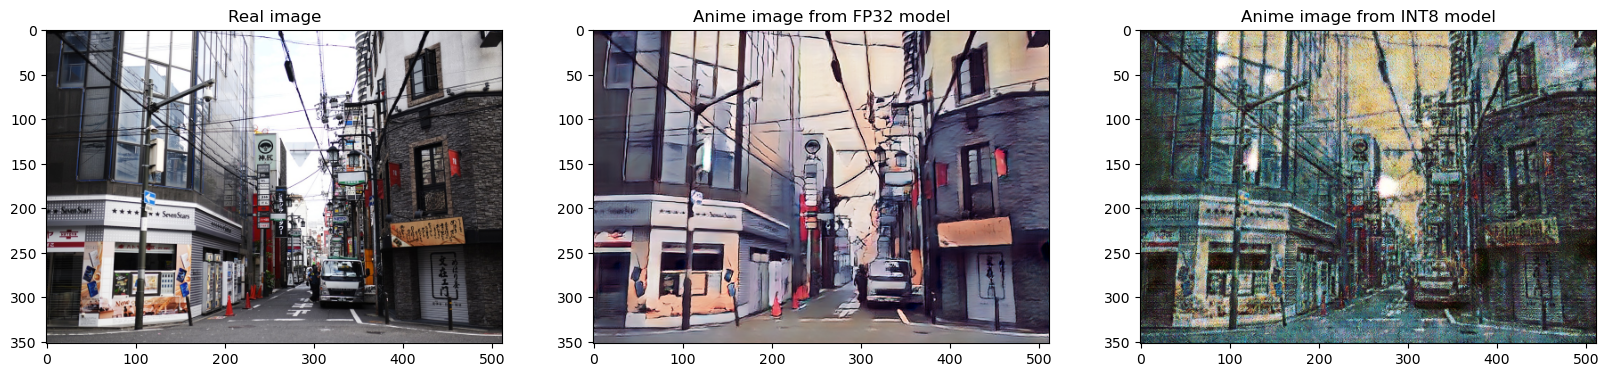

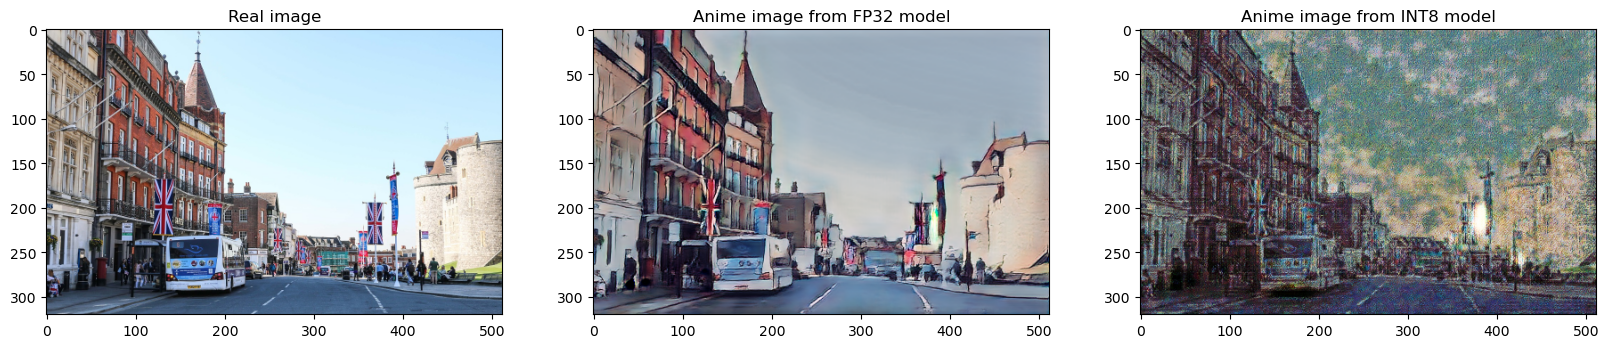

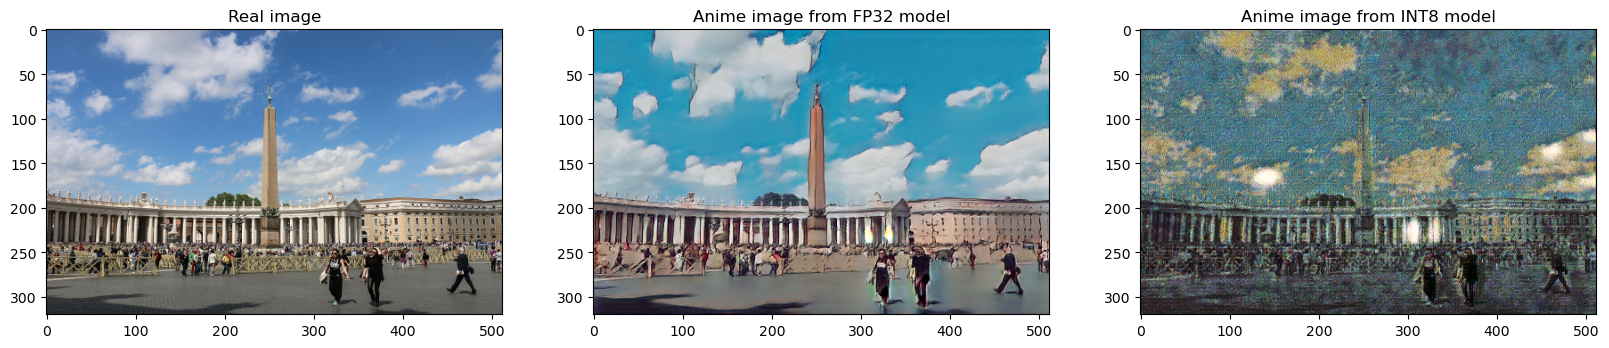

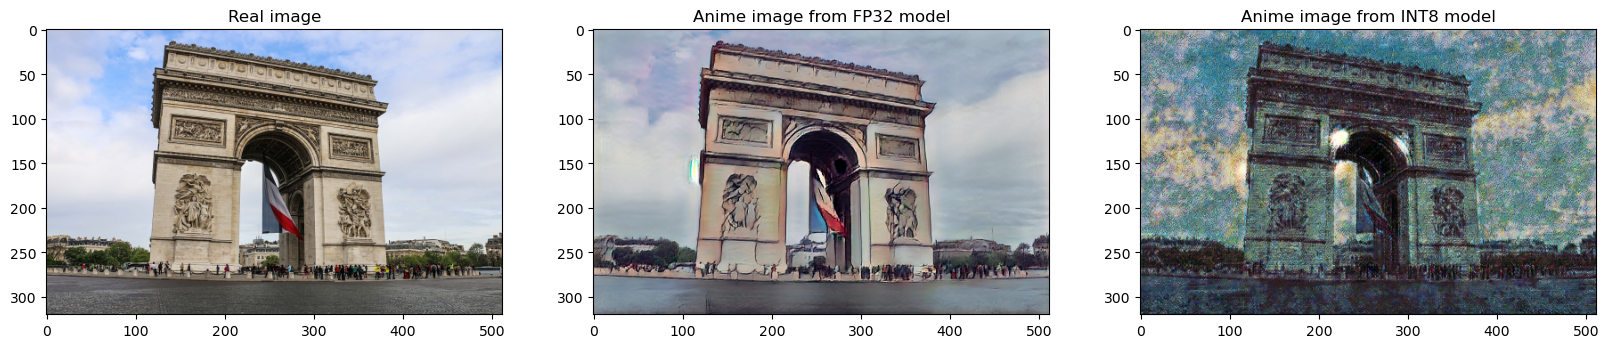

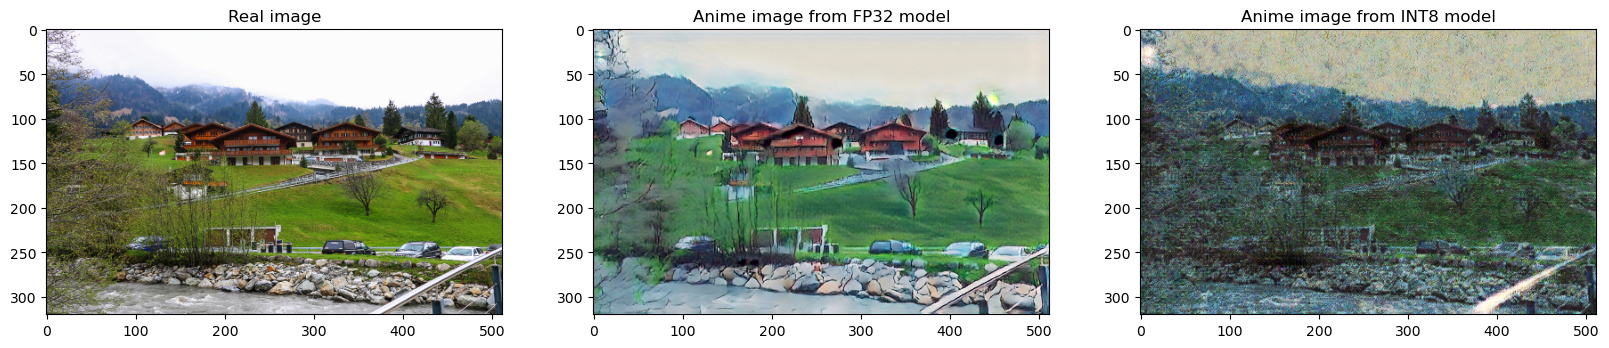

In [25]:
quantized_generator.train()
with torch.no_grad():
    for i in range(5):
        real_image = test_dataset[i].unsqueeze(0)
        anime_image_fp32 = generator(real_image)
        anime_image_int8 = quantized_jit_generator(real_image)
    
        real_image = denormalize_input(real_image, torch.int16)[0]
        anime_image_fp32 = denormalize_input(anime_image_fp32, torch.int16)[0]
        anime_image_int8 = denormalize_input(anime_image_int8, torch.int16)[0]
    
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        axes[0].imshow(real_image.permute(1,2,0))
        axes[0].set_title('Real image')
        axes[1].imshow(anime_image_fp32.permute(1,2,0))
        axes[1].set_title('Anime image from FP32 model')
        axes[2].imshow(anime_image_int8.permute(1,2,0))
        axes[2].set_title('Anime image from INT8 model')

Наблюдаем достаточно сильную потерю качества в случае инференса квантованной INT8 модели.

## Выводы

В ходе выполнения работы было проведено квантование модели AnimeGAN для задачи переноса стиля с целевым развертыванием на мобильном устройстве (Xiaomi Redmi Note 9 Pro с процессором Qualcomm Snapdragon 720G). Использовался подход Quantization-Aware Training (QAT) во фреймворке PyTorch.

### Основные результаты
1. Реализация пайплайна QAT
    - Разработан полный пайплайн квантизации, включающий подготовку модели, QAT-дообучение и конвертацию в INT8
    - Эксперименты проводились с бэкендом fbgemm, однако для целевого ARM-устройства рекомендуется использование qnnpack, который имеет оптимизации под архитектуру Snapdragon 720G 

2. Влияние на скорость и качество генерации
    - Квантование модели в INT8 дало ускорение почти в 5 раз по сравнению FP32 моделью на CPU. Использование JIT-модели дает выигрыш ещё в несколько миллисекунд
    - Квантованная INT8 модель демонстрирует ожидаемое снижение качества по сравнению с исходной FP32 моделью
    - Снижение PSNR составило 4.178 дБ, что соответствует заметному ухудшению пиксельной точности
    - Падение SSIM составило 0.344 пунктов, что указывает на критическую потерю структурного сходства с эталонными изображениями

4. Особенности квантизации генеративных моделей
    - В ходе экспериментов выявлено, что квантизация GAN-архитектур (в частности AnimeGAN) является более сложной задачей по сравнению с классификационными моделями
    - Генеративные модели чувствительны к точности вычислений, особенно в слоях, отвечающих за формирование текстур и контуров

### Причины снижения качества
1. **Потери при квантовании:** преобразование весов и активаций из fp32 в int8 вносит неизбежные ошибки округления, которые накапливаются в процессе генерации изображения
2. **Специфика AnimeGAN:** архитектура содержит слои с высокими требованиями к точности (нормализации, конкатенации, остаточные связи), которые чувствительны к снижению разрядности
3. **Ограничения QAT:** дообучение квантизованной модели ограничено по времени и объему данных, что не позволило полностью компенсировать потери точности